# Notebook 04: Análisis de resultados - modelos base

## Objetivo
Analizar en detalle las predicciones del mejor modelo (MLP) y comparar
el comportamiento de todos los modelos entrenados en el notebook 03.

## Flujo
1. Cargar modelos y datos de test
2. Tabla comparativa de métricas
3. Visualización de predicción vs. real (primera semana de test)
4. Análisis del error en kW: resumen estadístico
5. Distribución del error e interpretación del sesgo
6. Comparativa completa de todos los modelos en kW

## Criterios de interpretación
- Los errores se expresan en kW multiplicando por la potencia nominal de LECA1 (19.53 kW),
  lo que facilita la interpretación operativa del resultado.
- **Bias > 0** (error = Real - Predicho > 0): el modelo subestima la producció
- n real.
- **Bias < 0**: el modelo sobreestima la producción real.
- El error más alto se concentra en los picos de irradiancia del mediodia.


### 1. Configuración de rutas e importaciones


In [1]:
import json
import os
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

current = Path().resolve()
root = current.anchor
while not ((current / "data").exists() and (current / "src").exists()):
    if str(current) == root:
        raise FileNotFoundError(
            "No se encontro la raíz del proyecto. "
            "Asegurate de que existen las carpetas data/ y src/."
        )
    current = current.parent

os.chdir(current)
if str(current) not in sys.path:
    sys.path.insert(0, str(current))

PROJECT_ROOT = current
DATA_DIR     = PROJECT_ROOT / "data"
SPLITS_DIR   = DATA_DIR / "splits"
MODELS_DIR   = DATA_DIR / "models"
RESULTS_DIR  = DATA_DIR / "results"

from src.evaluation import compute_metrics

warnings.filterwarnings("ignore", category=FutureWarning)
print(f"Raíz del proyecto: {PROJECT_ROOT.name}")


Raíz del proyecto: TFM_RPUEBAS


### 2. Carga de datos y modelos
Se carga el conjunto de test (LECA1, mar-may 2024) y los modelos
serializados en el notebook 03.


In [2]:
test_df = pd.read_csv(SPLITS_DIR / "test.csv", parse_dates=["timestamp"])

with open(SPLITS_DIR / "feature_cols.json", encoding="utf-8") as f:
    FEATURE_COLS = json.load(f)

TARGET       = "power_pu"
NOMINAL_LECA1 = 19.53  # kW

X_test = test_df[FEATURE_COLS]
y_test = test_df[TARGET]

# Cargar modelos guardados
model_names = [
    "MLP", "Ridge", "XGBoost", "LightGBM",
    "CatBoost", "Random_Forest", "ExtraTrees",
]
trained_models = {}
for name in model_names:
    model_path = MODELS_DIR / f"{name}.pkl"
    if model_path.exists():
        trained_models[name] = joblib.load(model_path)
    else:
        print(f"Modelo no encontrado: {model_path.name}")

print(f"Modelos cargados: {list(trained_models.keys())}")
print(f"Test: {X_test.shape} | zeros: {(y_test == 0).mean():.1%}")


Modelos cargados: ['MLP', 'Ridge', 'XGBoost', 'LightGBM', 'CatBoost', 'Random_Forest', 'ExtraTrees']
Test: (8639, 32) | zeros: 44.2%


### 3. Tabla comparativa de métricas
Resultados del notebook 03 en kW, ordenados por RMSE sobre el conjunto
de *test* (LECA1).


In [3]:
results = pd.read_csv(RESULTS_DIR / "results_kw_base.csv")
display(results.sort_values("RMSE (kW)").round(4))


,Modelo,MAE (kW),RMSE (kW),R2,Bias (kW),MAE_luz (kW),RMSE_luz (kW),R2_luz,Bias_luz (kW)
0,MLP,0.3276,0.8563,0.9738,0.0714,0.5662,1.1408,0.9577,0.1334
1,Ridge,0.3578,0.8694,0.9730,0.0245,0.5916,1.1439,0.9574,0.0269
2,XGBoost,0.4817,1.0059,0.9638,0.2474,0.8549,1.3428,0.9413,0.4502
3,LightGBM,0.4956,1.0214,0.9627,0.2514,0.8819,1.3659,0.9393,0.4548
4,CatBoost,0.5103,1.0378,0.9615,0.2405,0.9061,1.3879,0.9373,0.4370
5,Random Forest,0.4753,1.0538,0.9603,0.1959,0.8399,1.3960,0.9366,0.3621
6,ExtraTrees,0.5504,1.1477,0.9529,0.2325,0.9744,1.5277,0.9241,0.4275


### 4. Predicción vs. real - mejor modelo (MLP)
Se visualiza la primera semana del periodo de *test* para analizar la
capacidad del modelo de seguir la curva de generación diaria.


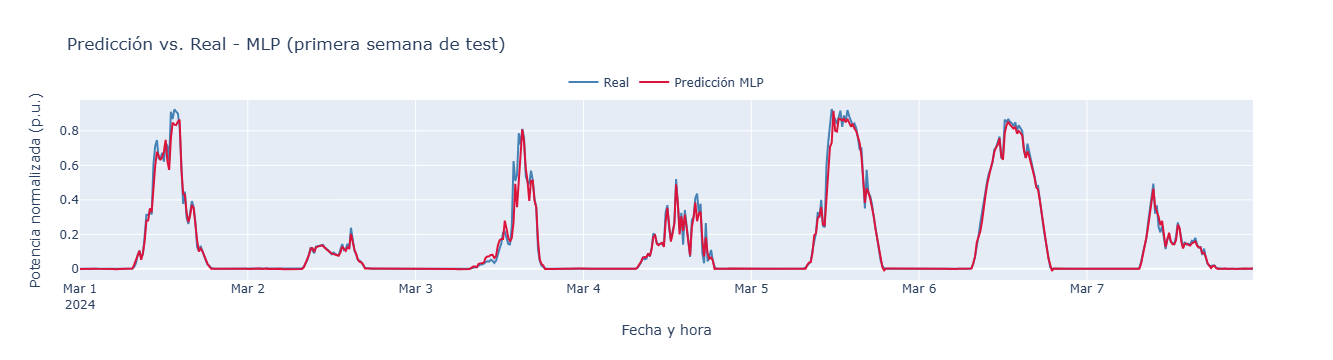

In [9]:
best_model_name = "MLP"
best_model = trained_models[best_model_name]
y_pred = best_model.predict(X_test)

df_plot = test_df[["timestamp", "power_pu"]].copy()
df_plot["y_pred"] = y_pred

# Zoom en la primera semana del test
df_zoom = df_plot[
    df_plot["timestamp"] < df_plot["timestamp"].min() + pd.Timedelta(days=7)
]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_zoom["timestamp"], y=df_zoom["power_pu"],
    name="Real", line=dict(color="steelblue"),
))
fig.add_trace(go.Scatter(
    x=df_zoom["timestamp"], y=df_zoom["y_pred"],
    name=f"Predicción {best_model_name}", line=dict(color="crimson", dash="solid"),
))
fig.update_layout(
    title=f"Predicción vs. Real - {best_model_name} (primera semana de test)",
    xaxis_title="Fecha y hora",
    yaxis_title="Potencia normalizada (p.u.)",
    hovermode="x unified",
    legend=dict(
    orientation="h",
    yanchor="bottom",
    y=1.02,
    xanchor="center",
    x=0.5
)
)
fig.show()


### 5. Resumen estadístico del error en kW
El error se define como `Real - Predicho`: valores positivos indican
subestimación y valores negativos indican sobreestimación.


In [10]:
error_kw = (y_test.values - y_pred) * NOMINAL_LECA1
bias_direction = "subestima" if error_kw.mean() > 0 else "sobreestima"

print(f"Resumen del error (kW) — {best_model_name}:")
print(f"  Definición: error = Real - Predicho")
print(f"  Bias medio: {error_kw.mean():.4f} kW  ({bias_direction})")
print(f"  MAE:        {np.abs(error_kw).mean():.4f} kW")
print(f"  RMSE:       {np.sqrt((error_kw**2).mean()):.4f} kW")
print(f"  Std:        {error_kw.std():.4f} kW")
print(f"  Min / Max:  {error_kw.min():.3f} / {error_kw.max():.3f} kW")


Resumen del error (kW) — MLP:
  Definición: error = Real - Predicho
  Bias medio: 0.0714 kW  (subestima)
  MAE:        0.3276 kW
  RMSE:       0.8563 kW
  Std:        0.8533 kW
  Min / Max:  -14.814 / 8.617 kW


### 6. Distribución del error y gráfico de valores real frente a predichos
El histograma muestra la simetría de la distribución del error y
el sesgo sistemático. El gráfico de dispersión de Real vs. Predicho (solo horas de
producción) permite identificar si el modelo pierde precisión en
los valores extremos.


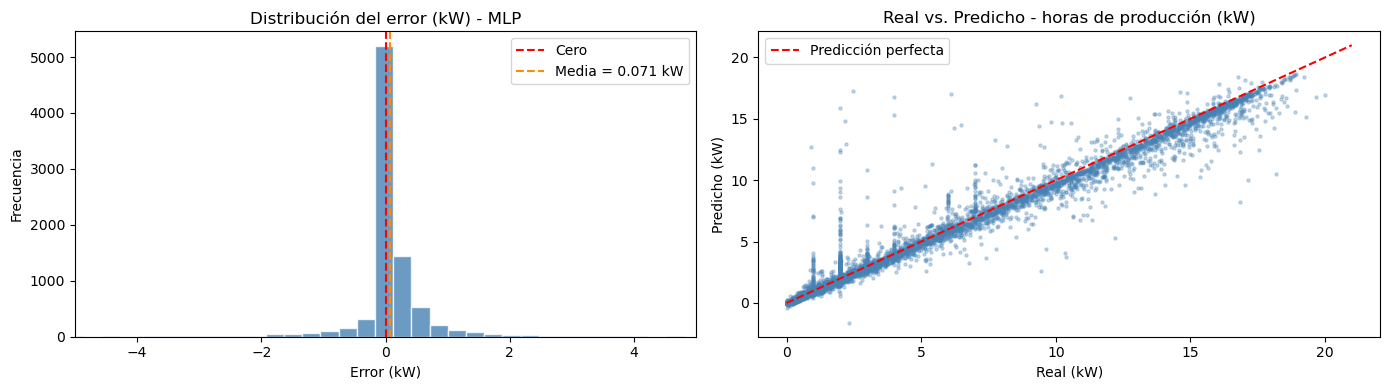

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma del error
axes[0].hist(error_kw, bins=80, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_xlim(-5, 5)
axes[0].axvline(0, color="red", linestyle="--", label="Cero")
axes[0].axvline(
    error_kw.mean(), color="darkorange", linestyle="--",
    label=f"Media = {error_kw.mean():.3f} kW",
)
axes[0].set_title(f"Distribución del error (kW) - {best_model_name}")
axes[0].set_xlabel("Error (kW)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# Real vs. Predicho (solo horas de produccion)
mask_day = y_test.values > 0
real_kw = y_test.values[mask_day] * NOMINAL_LECA1
pred_kw = y_pred[mask_day] * NOMINAL_LECA1
lim = max(real_kw.max(), pred_kw.max()) * 1.05

axes[1].scatter(real_kw, pred_kw, alpha=0.3, s=5, color="steelblue")
axes[1].plot([0, lim], [0, lim], "r--", label="Predicción perfecta")
axes[1].set_title("Real vs. Predicho - horas de producción (kW)")
axes[1].set_xlabel("Real (kW)")
axes[1].set_ylabel("Predicho (kW)")
axes[1].legend()

plt.tight_layout()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(RESULTS_DIR / "error_distribution_MLP.png", dpi=150, bbox_inches="tight")
plt.show()


### 7. Comparativa de todos los modelos en kW
Se recalculan las métricas en kW para todos los modelos cargados,
incluyendo el error en horas de producción.


In [12]:
results_all = []
mask_day = y_test.values > 0

for name, model in trained_models.items():
    yp = model.predict(X_test)
    err = (y_test.values - yp) * NOMINAL_LECA1
    ss_res = np.sum((y_test.values - yp) ** 2)
    ss_tot = np.sum((y_test.values - y_test.mean()) ** 2)
    results_all.append({
        "Modelo":         name,
        "MAE (kW)":       np.abs(err).mean(),
        "RMSE (kW)":      np.sqrt((err ** 2).mean()),
        "R2":             1 - ss_res / ss_tot,
        "Bias (kW)":      err.mean(),
        "MAE_luz (kW)":   np.abs(err[mask_day]).mean(),
        "RMSE_luz (kW)":  np.sqrt((err[mask_day] ** 2).mean()),
    })

df_all_results = pd.DataFrame(results_all).sort_values("RMSE (kW)")
display(df_all_results.round(4))


,Modelo,MAE (kW),RMSE (kW),R2,Bias (kW),MAE_luz (kW),RMSE_luz (kW)
0,MLP,0.3276,0.8563,0.9738,0.0714,0.5662,1.1408
1,Ridge,0.3578,0.8694,0.9730,0.0245,0.5916,1.1439
2,XGBoost,0.4817,1.0059,0.9638,0.2474,0.8549,1.3428
3,LightGBM,0.4956,1.0214,0.9627,0.2514,0.8819,1.3659
4,CatBoost,0.5103,1.0378,0.9615,0.2405,0.9061,1.3879
5,Random_Forest,0.4753,1.0538,0.9603,0.1959,0.8399,1.3960
6,ExtraTrees,0.5504,1.1477,0.9529,0.2325,0.9744,1.5277


### 8. Gráfico comparativo de RMSE en horas de producción


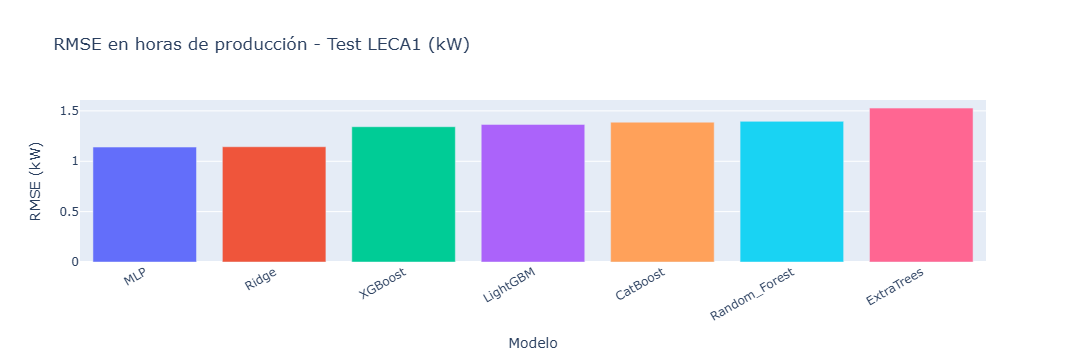

In [14]:
fig = px.bar(
    df_all_results.sort_values("RMSE_luz (kW)"),
    x="Modelo", y="RMSE_luz (kW)", color="Modelo",
    title="RMSE en horas de producción - Test LECA1 (kW)",
    labels={"RMSE_luz (kW)": "RMSE (kW)"},
)
fig.update_layout(showlegend=False, xaxis_tickangle=-30)
fig.show()


### 9. Scatter real vs. predicho desagregado por mes
Un gráfico *scatter* global puede ocultar comportamientos deficientes del modelo en determinados meses.
En este apartado se representa la nube de puntos real vs. predicha de forma desagregada por mes,
considerando únicamente las horas con producción fotovoltaica, junto con la diagonal correspondiente a la predicción perfecta.


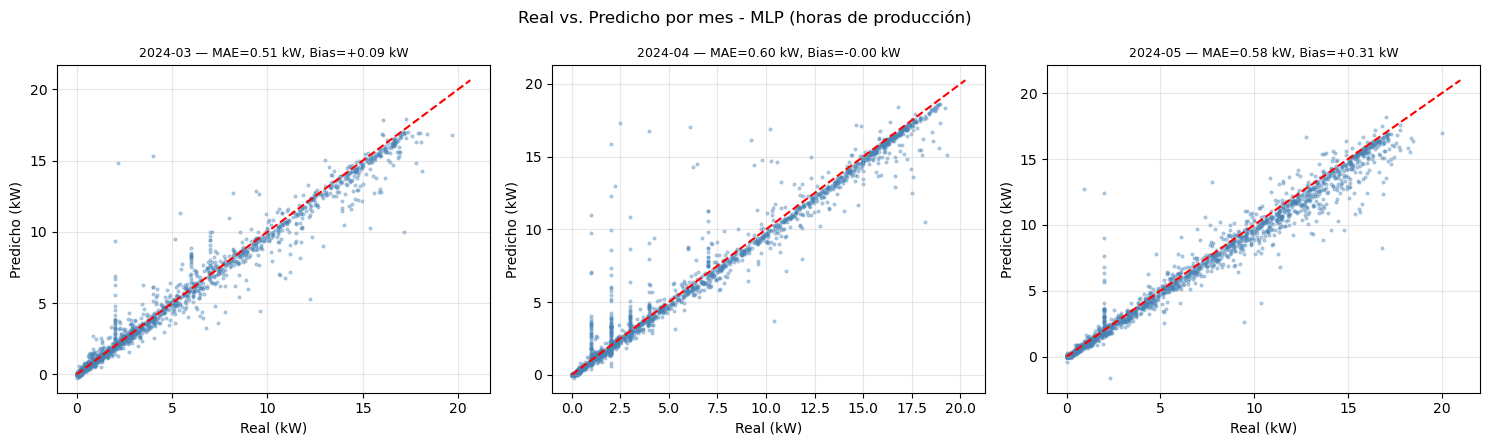

Figura guardada en data/results/scatter_real_pred_por_mes.png


In [16]:
# Máscara de horas con producción
mask_day = y_test.values > 0

# Copia solo de las muestras diurnas
test_day = test_df[mask_day].copy()

# Predicción completa una sola vez
y_pred = trained_models[best_model_name].predict(test_df[FEATURE_COLS])

# Aplicamos máscara
test_day["y_pred"] = y_pred[mask_day]

# Conversión a kW
test_day["real_kw"] = test_day["power_pu"] * NOMINAL_LECA1
test_day["pred_kw"] = test_day["y_pred"] * NOMINAL_LECA1

# Mes
test_day["mes"] = test_day["timestamp"].dt.strftime("%Y-%m")

meses = sorted(test_day["mes"].unique())
n_cols = min(3, len(meses))
n_rows = (len(meses) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5 * n_cols, 4.5 * n_rows),
                         squeeze=False)

for idx, mes in enumerate(meses):
    ax = axes[idx // n_cols][idx % n_cols]
    sub = test_day[test_day["mes"] == mes]
    ax.scatter(sub["real_kw"], sub["pred_kw"],
               s=4, alpha=0.35, color="steelblue")
    lim = max(sub["real_kw"].max(), sub["pred_kw"].max()) * 1.05
    ax.plot([0, lim], [0, lim], "r--", lw=1.5, label="Pred. perfecta")
    mae_m  = (sub["real_kw"] - sub["pred_kw"]).abs().mean()
    bias_m = (sub["real_kw"] - sub["pred_kw"]).mean()
    ax.set_title("{} — MAE={:.2f} kW, Bias={:+.2f} kW".format(mes, mae_m, bias_m),
                 fontsize=9)
    ax.set_xlabel("Real (kW)"); ax.set_ylabel("Predicho (kW)")
    ax.grid(alpha=0.3)

# Ocultar ejes sobrantes
for idx in range(len(meses), n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].set_visible(False)

plt.suptitle(
    "Real vs. Predicho por mes - {} (horas de producción)".format(best_model_name),
    fontsize=12,
)
plt.tight_layout()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(RESULTS_DIR / "scatter_real_pred_por_mes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada en data/results/scatter_real_pred_por_mes.png")


### 10. Comparativa visual de todos los modelos en una semana
Prediccion de los 7 modelos sobre la misma semana de referencia
(primera semana del test). Permite ver visualmente que modelos
siguen mejor la curva real de producción.


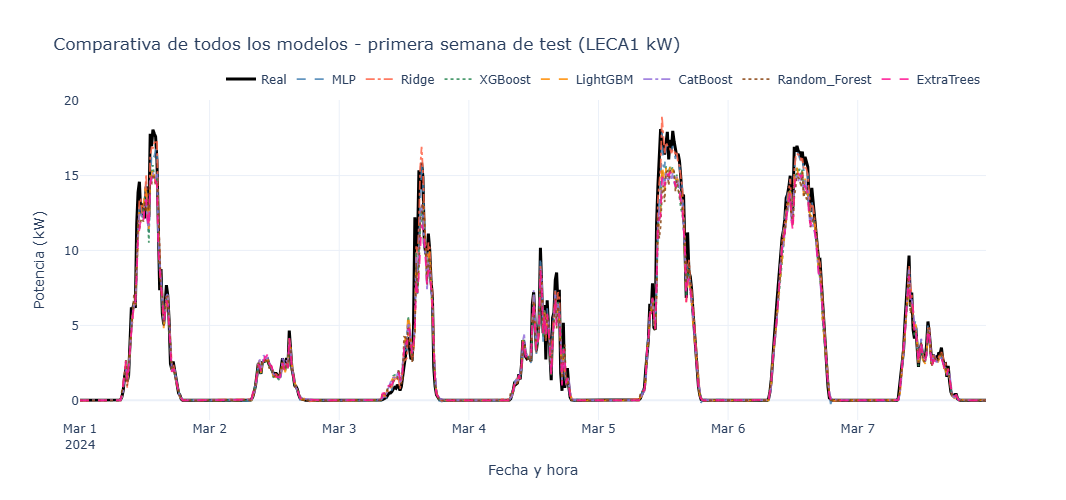

Figura interactiva guardada en: C:\Users\admin\anaconda3\envs\TFM\TFM_RPUEBAS\data\results\comparativa_todos_modelos_semana_interactivo.html


In [21]:
import plotly.graph_objects as go
import plotly.io as pio

# Semana de referencia: primeros 7 días del test
start_ref = test_df["timestamp"].min()
end_ref   = start_ref + pd.Timedelta(days=7)

df_week = test_df[
    (test_df["timestamp"] >= start_ref) &
    (test_df["timestamp"] < end_ref)
].copy()

X_week = df_week[FEATURE_COLS]

# Figura interactiva
fig = go.Figure()

# Serie real
fig.add_trace(
    go.Scatter(
        x=df_week["timestamp"],
        y=df_week[TARGET] * NOMINAL_LECA1,
        mode="lines",
        name="Real",
        line=dict(color="black", width=3),
    )
)

# Colores y estilos
colors = [
    "steelblue", "tomato", "seagreen",
    "darkorange", "mediumpurple",
    "saddlebrown", "deeppink"
]

dash_styles = [
    "dash", "dashdot", "dot",
    "dash", "dashdot", "dot", "dash"
]

# Modelos
for (name, model), color, dash in zip(
    trained_models.items(),
    colors,
    dash_styles
):

    y_w = model.predict(X_week) * NOMINAL_LECA1

    fig.add_trace(
        go.Scatter(
            x=df_week["timestamp"],
            y=y_w,
            mode="lines",
            name=name,
            line=dict(color=color, width=1.8, dash=dash),
            opacity=0.85,
        )
    )

# Layout
fig.update_layout(
    title="Comparativa de todos los modelos - primera semana de test (LECA1 kW)",
    xaxis_title="Fecha y hora",
    yaxis_title="Potencia (kW)",
    template="plotly_white",
    hovermode="x unified",
    height=500,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

# Mostrar
fig.show()

# Guardar HTML interactivo
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

html_path = RESULTS_DIR / "comparativa_todos_modelos_semana_interactivo.html"

pio.write_html(
    fig,
    file=str(html_path),
    auto_open=False
)

print(f"Figura interactiva guardada en: {html_path}")

## Conclusiones del notebook 04

**Distribución del error (MLP):**
- La distribución es aproximadamente simétrica, centrada ligeramente por
  encima de cero (*bias* positivo = sobreestimacion marginal de media).
- Las colas largas corresponden a los picos de irradiancia del mediodia,
  donde el modelo pierde precisión en los valores extremos.
- El modelo captura bien la forma general de la curva de generación diaria.

**Comparativa de modelos en kW:**

| Modelo | MAE (kW) | RMSE (kW) | R2 | Bias (kW) | MAE_luz (kW) | RMSE_luz (kW) |
|---|---:|---:|---:|---:|---:|---:|
| MLP | 0.3276 | 0.8563 | 0.9738 | 0.0714 | 0.5662 | 1.1408 |
| Ridge | 0.3578 | 0.8694 | 0.9730 | 0.0245 | 0.5916 | 1.1439 |
| XGBoost | 0.4817 | 1.0059 | 0.9638 | 0.2474 | 0.8549 | 1.3428 |
| LightGBM | 0.4956 | 1.0214 | 0.9627 | 0.2514 | 0.8819 | 1.3659 |
| CatBoost | 0.5103 | 1.0378 | 0.9615 | 0.2405 | 0.9061 | 1.3879 |
| Random Forest | 0.4753 | 1.0538 | 0.9603 | 0.1959 | 0.8399 | 1.3960 |
| ExtraTrees | 0.5504 | 1.1477 | 0.9529 | 0.2325 | 0.9744 | 1.5277 |

- MLP y Ridge generalizan mejor a LECA1 en todas las metricas.
- Los modelos de *boosting* muestran un sesgo positivo sistemático en kW,
  indicando sobrepredicción en la planta no vista.
- La métrica en horas de luz es más exigente en todos los casos, lo que
  confirma que los ceros nocturnos enmascaran parte del error real.

**Siguiente paso:** análisis de la contribución de la memoria temporal (notebook 05).
